# Causal AI: when the pattern you learn is the policy you used
### A single-notebook experiment in commodity procurement hedging

**Question:** can a Transformer-PPO policy learn a seasonal price pattern generated by the company's own liquidation schedule—and does training on explicit interventions change its behavior when that schedule changes?

This notebook puts the full model code, economic assumptions, experiment, data tables and rendered charts in one reading sequence. The notebook is the single source of the experiment code. **You do not need to open other code files to follow or run it**; the automated tests load these definitions directly.

**Two distinct sources of evidence:**

- **Synthetic causal experiment:** a known structural model, with company liquidation effects specified by us. It is not causal discovery from market prices.
- **Real market context:** free daily WTI observations from EIA via FRED. Those prices alone do not identify a company's liquidation effect.

The saved outputs come from executing every code cell, including all six policy-training runs. GitHub can display the notebook without running Python.

## Reading and running

Read top to bottom, or jump to [results](#7-Measured-results-and-baselines) and [real market data](#9-Real-market-context:-WTI).

For a fresh environment, run this once in a notebook cell:

```python
%pip install "numpy>=1.26,<3" "pandas>=2.2,<4" "torch>=2.2,<3" "matplotlib>=3.8,<4" ipykernel
```

Then **Restart Kernel → Run All**. The full run uses CPU and may take a few minutes. From a cloned repository, `pip install -r requirements.txt` installs the notebook dependencies and JupyterLab. Exact reference model-library versions are in `requirements-reference.txt`.

The notebook is self-contained in code. It writes generated results into `notebook-runs/`, leaving committed reference results unchanged. The WTI section reads the separate `data/` snapshot when available; a standalone copy downloads public WTI data when it reaches that section. Set `REFRESH_WTI=True` to request a new snapshot explicitly.


In [1]:
import hashlib
import io
import json
import math
import platform
from dataclasses import asdict, dataclass
from datetime import UTC, datetime
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.distributions import Categorical

%matplotlib inline

SEEDS = [11, 22, 33]
STEPS = 4096
TEST_PATHS = 8
REFRESH_WTI = False
ROOT = Path.cwd()
RUN_DIR = ROOT / "notebook-runs" / "full-experiment"
DATA_DIR = ROOT / "data"

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
pd.set_option("display.precision", 3)
plt.rcParams.update({
    "figure.figsize": (13, 4.8), "figure.dpi": 120,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.2,
    "font.size": 11, "axes.titleweight": "bold",
})
COLORS = {"Observational PPO": "#dc674d", "Interventional PPO": "#138e82",
          "Always hedge": "#71809b", "Never hedge": "#a876c6", "50% hedge": "#c59b35"}
display(pd.Series({"Python": platform.python_version(), "PyTorch": torch.__version__,
                   "NumPy": np.__version__, "Seeds": str(SEEDS),
                   "Training steps / policy": STEPS, "Test paths / seed": TEST_PATHS},
                  name="Execution configuration").to_frame())


,Execution configuration
Python,3.12.14
PyTorch,2.14.0
NumPy,2.5.3
Seeds,"[11, 22, 33]"
Training steps / policy,4096
Test paths / seed,8


## 1 · Define the economic question

The business exposure is a **future commodity purchase**. Remaining unhedged can help if prices fall; this is not the mark-to-market P&L of already-owned inventory.

For a hedge fraction $h$ and four-week horizon $H$:

$$c_t=(1-h)(P_{t+H}-P_t)+0.15h,$$
$$u_t=-c_t-0.04\max(c_t,0)^2.$$

Positive cost means paying more than locking all volume at today's spot price before fees. The agent maximizes a risk-penalized utility, not raw profit. Weekly decisions cover separate procurement tranches; they do not form one self-financing trading portfolio. Costs are **synthetic index units**, not investment returns.

This simplified hedge locks today's spot-price proxy. Futures basis, margin, financing, position limits and market impact from the hedge itself are outside the model.

## 2 · Specify the structural causal model

$$P_t=100+1.5\sin(2\pi(w_t-1)/52)+U_t-8L_t+S_t,\quad U_t\sim N(0,0.7^2).$$

- $L_t$: the company's liquidation decision. It occurs in Q4 before entry, then in Q3 when the company responds to competitor entry at the start of **calendar year 9**.
- $S_t$: an unseen January year-10 supply shock, initially 12 index points, decaying over time.
- The sine is a deterministic exogenous seasonal component; $U_t$ is stochastic noise.

The competitor changes the company's schedule in this story; it has no separate price-effect term. This is a precise, specified scenario, not a factual reconstruction of a commodity market.


In [2]:
@dataclass(frozen=True)
class Config:
    years: int = 10
    history: int = 104
    entry_year: int = 8  # zero based: beginning of calendar year 9
    horizon: int = 4
    liquidation_effect: float = 8.0
    shock_size: float = 12.0
    hedge_fee: float = 0.15
    risk_aversion: float = 0.04


DEFAULT_CONFIG = Config()


@dataclass
class World:
    price: np.ndarray
    seasonal: np.ndarray
    noise: np.ndarray
    liquidation: np.ndarray
    shock: np.ndarray


def make_world(seed: int, config: Config = DEFAULT_CONFIG, intervention: str = "observed") -> World:
    """Same seed preserves exogenous disturbances across liquidation interventions.

    `observed`: company liquidates in Q4 until competitor entry, then Q3.
    `none`, `q3`, `q4`: replace the entire company liquidation equation.
    Competitor entry changes the company's schedule; no direct competitor price effect.
    """
    if intervention not in {"observed", "none", "q3", "q4"}:
        raise ValueError(f"Unknown intervention: {intervention}")
    rng = np.random.default_rng(seed)
    t = np.arange(config.years * 52)
    week, year = t % 52 + 1, t // 52
    seasonal = 1.5 * np.sin(2 * np.pi * (week - 1) / 52)
    noise = rng.normal(0, 0.7, t.size)
    if intervention == "observed":
        liquidation = np.where(year < config.entry_year, week >= 40, (week >= 27) & (week <= 39))
    elif intervention == "none":
        liquidation = np.zeros(t.size, dtype=bool)
    elif intervention == "q3":
        liquidation = (week >= 27) & (week <= 39)
    else:
        liquidation = week >= 40
    # Held-out stress: January of calendar year 10. Never used in training.
    elapsed = t - (config.entry_year + 1) * 52
    shock = np.where(elapsed >= 0, config.shock_size * np.exp(-np.maximum(elapsed, 0) / 8), 0)
    price = 100 + seasonal + noise - config.liquidation_effect * liquidation + shock
    return World(price, seasonal, noise, liquidation.astype(float), shock)


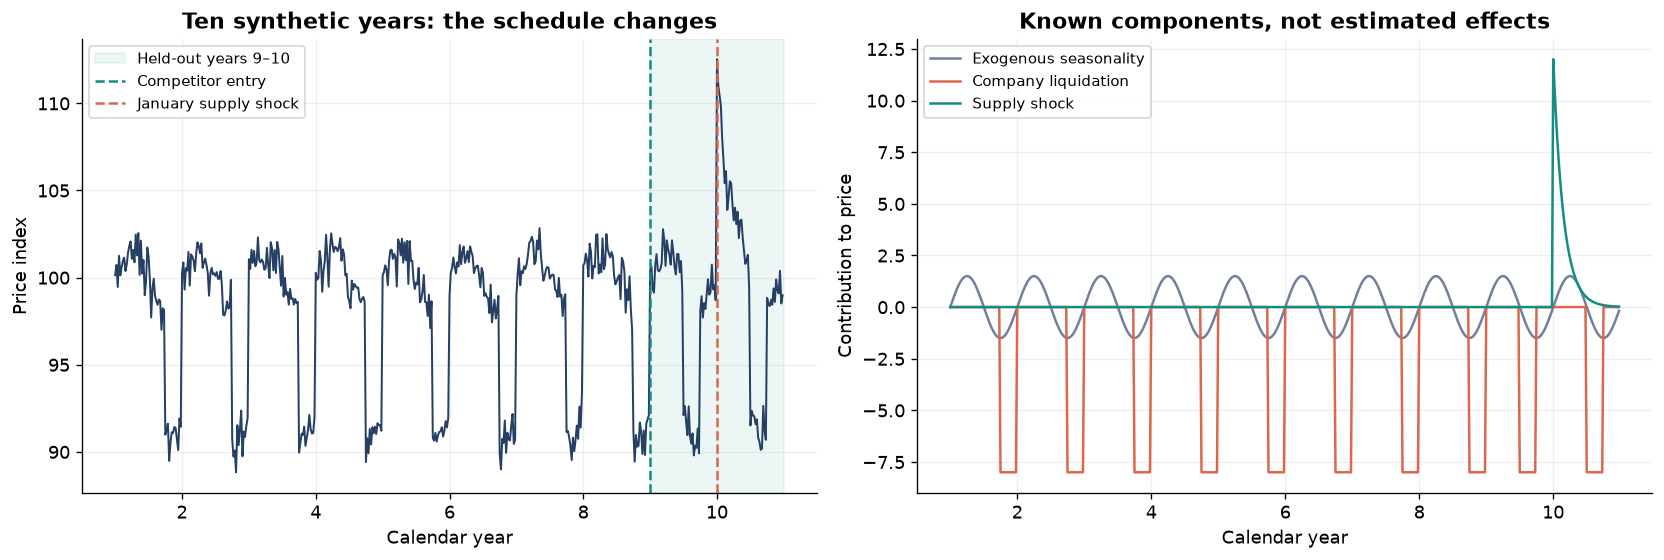

In [3]:
config = Config()
world = make_world(10000, config)
t = np.arange(len(world.price))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(t / 52 + 1, world.price, color="#263f65", linewidth=1.2)
axes[0].axvspan(9, 11, color="#138e82", alpha=0.08, label="Held-out years 9–10")
axes[0].axvline(9, color="#138e82", linestyle="--", label="Competitor entry")
axes[0].axvline(10, color="#dc674d", linestyle="--", label="January supply shock")
axes[0].set(title="Ten synthetic years: the schedule changes", xlabel="Calendar year", ylabel="Price index")
axes[0].legend(fontsize=9)
axes[1].plot(t / 52 + 1, world.seasonal, label="Exogenous seasonality", color="#71809b")
axes[1].plot(t / 52 + 1, -config.liquidation_effect * world.liquidation,
             label="Company liquidation", color="#dc674d")
axes[1].plot(t / 52 + 1, world.shock, label="Supply shock", color="#138e82")
axes[1].set(title="Known components, not estimated effects", xlabel="Calendar year", ylabel="Contribution to price")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()


## 3 · Intervene on liquidation, keeping the shocks fixed

A counterfactual question changes a mechanism: **what would the price path be if the company did not liquidate in Q4?** We compare `none` and `q4` schedules with the same noise realization and supply shock.

In this known additive model, $P_t^{do(Q4)}-P_t^{do(none)}=-8$ during Q4 and zero otherwise. This follows from the assumed structural equation. It is not an estimate extracted from WTI data.

Adding random noise to the observed history would not perform this intervention. Replacing the liquidation equation does.


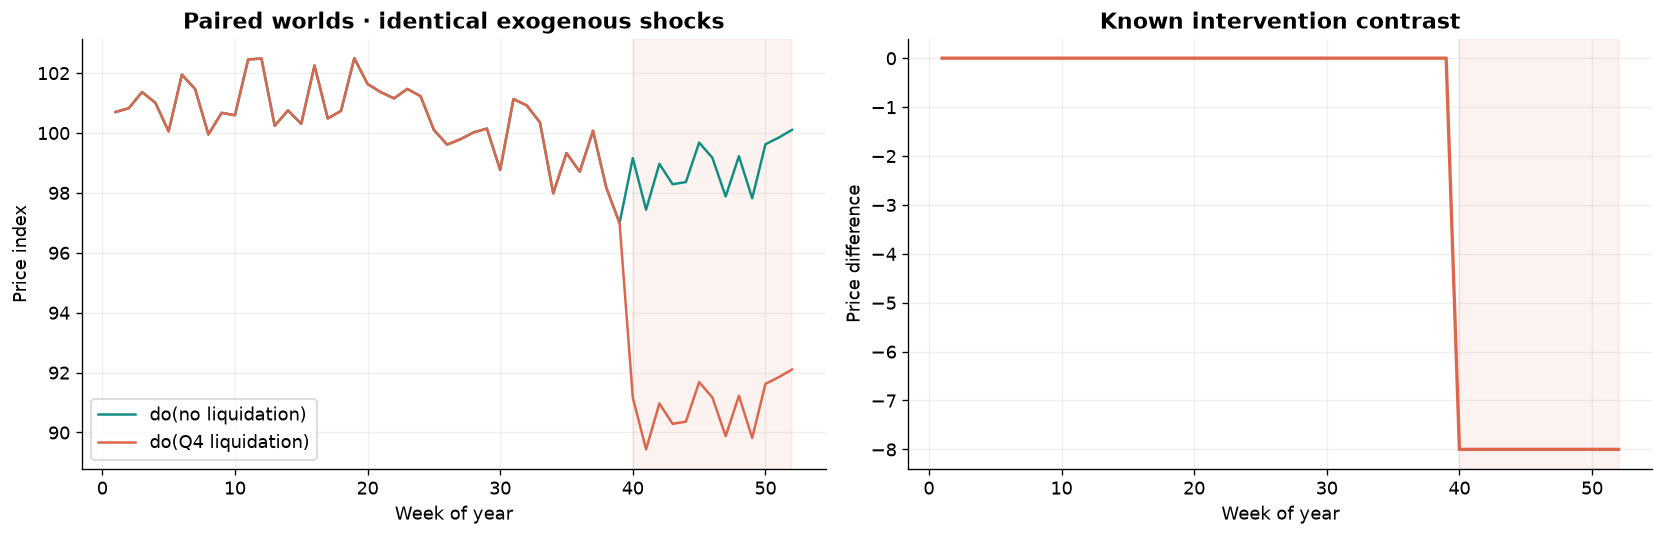

Verified: only the liquidation mechanism changes between the paired worlds.


In [4]:
no_liquidation = make_world(10000, config, "none")
q4_liquidation = make_world(10000, config, "q4")
np.testing.assert_array_equal(no_liquidation.noise, q4_liquidation.noise)
np.testing.assert_array_equal(no_liquidation.shock, q4_liquidation.shock)
contrast = q4_liquidation.price - no_liquidation.price
np.testing.assert_allclose(contrast, -8 * (t % 52 + 1 >= 40))

weeks = np.arange(1, 53)
year8 = slice(7 * 52, 8 * 52)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(weeks, no_liquidation.price[year8], label="do(no liquidation)", color="#138e82")
axes[0].plot(weeks, q4_liquidation.price[year8], label="do(Q4 liquidation)", color="#dc674d")
axes[0].set(title="Paired worlds · identical exogenous shocks", xlabel="Week of year", ylabel="Price index")
axes[0].legend()
axes[1].plot(weeks, contrast[year8], color="#dc674d", linewidth=2)
axes[1].set(title="Known intervention contrast", xlabel="Week of year", ylabel="Price difference")
for ax in axes:
    ax.axvspan(40, 52, color="#dc674d", alpha=0.08)
fig.tight_layout()
plt.show()
print("Verified: only the liquidation mechanism changes between the paired worlds.")


## 4 · Build the information set and training environments

Each decision sees **104 weekly prices** and cyclical week features. It does not see future prices, the liquidation variable, or the true seasonal decomposition. Price normalization uses fixed simulator constants, not held-out statistics.

Both policies train on the first eight years with an initial 104-observation warmup. Every four-week reward target remains strictly before year 9.

The observational environment replays the historical Q4 rule. The interventional environment samples `observed`, `none`, `q3` or `q4` at each episode reset, preserving the same historical exogenous noise. Thus the interventional policy receives extra structural knowledge via its training distribution. This is an **oracle-SCM intervention-training comparison**, not evidence that it learned causal structure without supervision.


In [5]:
def features(world: World, t: int, history: int = 104) -> np.ndarray:
    """Information available at decision time t; no future prices or hidden effects."""
    if t < history - 1 or t >= len(world.price):
        raise ValueError("Insufficient history or decision outside world")
    idx = np.arange(t - history + 1, t + 1)
    angle = 2 * np.pi * (idx % 52) / 52
    return np.stack(((world.price[idx] - 100) / 10, np.sin(angle), np.cos(angle)), -1).astype(
        np.float32
    )


def procurement_outcome(world: World, t: int, hedge: float, config: Config) -> tuple[float, float]:
    """Independent four-week procurement tranche; a hedge locks today's spot proxy.

    Positive cost = worse than locking all volume at today's spot, before fees.
    Utility penalizes positive cost quadratically. No inventory/futures basis model.
    """
    delta = world.price[t + config.horizon] - world.price[t]
    cost = (1 - hedge) * delta + config.hedge_fee * hedge
    utility = -cost - config.risk_aversion * max(cost, 0) ** 2
    return float(cost), float(utility)


class TrainingEnv:
    """Replay eight historical years, or sample explicit liquidation interventions."""

    def __init__(self, causal: bool, seed: int, config: Config = DEFAULT_CONFIG):
        self.causal, self.seed, self.config = causal, seed, config
        self.rng = np.random.default_rng(seed)
        self.t = config.history - 1
        self.world = make_world(seed, config)

    def reset(self) -> np.ndarray:
        schedule = self.rng.choice(["observed", "none", "q3", "q4"]) if self.causal else "observed"
        self.world = make_world(self.seed, self.config, str(schedule))
        self.t = self.config.history - 1
        return features(self.world, self.t, self.config.history)

    def step(self, hedge: float) -> tuple[np.ndarray, float, bool]:
        _, utility = procurement_outcome(self.world, self.t, hedge, self.config)
        self.t += 1
        # Last training target is strictly before entry: no future regime leakage.
        done = self.t + self.config.horizon >= self.config.entry_year * 52
        return features(self.world, self.t, self.config.history), utility / 10, done


In [6]:
state = features(world, 200, config.history)
assert state.shape == (104, 3)
altered = make_world(10000, config)
altered.price[201:] += 1000
np.testing.assert_array_equal(state, features(altered, 200, config.history))

env = TrainingEnv(causal=True, seed=11)
env.reset()
done, decisions = False, 0
while not done:
    assert env.t + config.horizon < config.entry_year * 52
    _, _, done = env.step(0.5)
    decisions += 1
print(f"Verified: {decisions} training decisions per episode; no target crosses the holdout boundary.")
print("Verified: changing future prices leaves the current information set unchanged.")


Verified: 309 training decisions per episode; no target crosses the holdout boundary.
Verified: changing future prices leaves the current information set unchanged.


## 5 · Transformer actor–critic and PPO

The last Transformer token attends to all 104 available observations. Two heads share its representation: the actor produces categorical probabilities over hedge fractions `[0, .25, .5, .75, 1]`; the critic estimates discounted utility.

This is an **actor–critic encoder**, not a separately trained price forecaster. Dropout is disabled so unchanged parameters give stable likelihoods. Discrete bounded actions avoid clipping a Gaussian action while still scoring it under the original density.


In [7]:
HEDGES = np.array([0.0, 0.25, 0.5, 0.75, 1.0], dtype=np.float32)


class Policy(nn.Module):
    def __init__(self, history: int = 104, width: int = 16):
        super().__init__()
        self.input = nn.Linear(3, width)
        position = torch.arange(history).unsqueeze(1)
        scale = torch.exp(torch.arange(0, width, 2) * (-math.log(10000) / width))
        encoding = torch.zeros(history, width)
        encoding[:, 0::2], encoding[:, 1::2] = (
            torch.sin(position * scale),
            torch.cos(position * scale),
        )
        self.register_buffer("position", encoding)
        layer = nn.TransformerEncoderLayer(width, 2, 32, dropout=0.0, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, 1, enable_nested_tensor=False)
        self.actor = nn.Linear(width, len(HEDGES))
        self.critic = nn.Linear(width, 1)

    def forward(self, state: torch.Tensor) -> tuple[Categorical, torch.Tensor]:
        embedded = self.encoder(self.input(state) + self.position)
        representation = embedded[:, -1]  # last query attends to all 104 available observations
        return Categorical(logits=self.actor(representation)), self.critic(representation).squeeze(
            -1
        )


PPO compares the probability of **the same sampled action in the same state** before and after an update. Log-probabilities and advantages must be matching one-dimensional vectors. GAE stops at terminal boundaries; the environment continues across rollout batches and resets only when its training episode ends.

The implementation below uses the clipped surrogate objective, a critic loss, entropy regularization and gradient clipping. Utilities are divided by 10 for training stability; reported economic costs and utilities are unscaled.


In [8]:
def gae(rewards, values, dones, bootstrap, gamma=0.99, lam=0.95):
    advantages = np.zeros(len(rewards), dtype=np.float32)
    carry, next_value = 0.0, bootstrap
    for i in reversed(range(len(rewards))):
        alive = 1 - dones[i]
        delta = rewards[i] + gamma * next_value * alive - values[i]
        carry = delta + gamma * lam * alive * carry
        advantages[i], next_value = carry, values[i]
    return advantages, advantages + np.asarray(values, dtype=np.float32)


def clipped_loss(new_logp, old_logp, advantage, clip=0.2):
    if new_logp.ndim != 1 or new_logp.shape != old_logp.shape or new_logp.shape != advantage.shape:
        raise ValueError("PPO likelihoods and advantages must be matching one-dimensional vectors")
    ratio = (new_logp - old_logp).exp()
    return -torch.minimum(ratio * advantage, ratio.clamp(1 - clip, 1 + clip) * advantage).mean()


def train(causal: bool, seed: int, steps: int = 4096, batch_steps: int = 256):
    if steps < 1:
        raise ValueError("steps must be positive")
    torch.manual_seed(seed)
    env = TrainingEnv(causal, seed)
    policy = Policy(env.config.history)
    optimizer = torch.optim.Adam(policy.parameters(), lr=3e-4)
    state = env.reset()  # persists between rollout batches
    log = []
    for start in range(0, steps, batch_steps):
        states, actions, old_logp, rewards, values, dones = [], [], [], [], [], []
        for _ in range(min(batch_steps, steps - start)):
            with torch.no_grad():
                distribution, value = policy(torch.from_numpy(state[None]))
                action = distribution.sample()
            states.append(state)
            actions.append(action.item())
            old_logp.append(distribution.log_prob(action).item())
            values.append(value.item())
            state, reward, done = env.step(float(HEDGES[action.item()]))
            rewards.append(reward)
            dones.append(done)
            if done:
                state = env.reset()
        with torch.no_grad():
            _, bootstrap = policy(torch.from_numpy(state[None]))
        advantage, returns = gae(rewards, values, dones, bootstrap.item())
        advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
        x = torch.from_numpy(np.stack(states))
        action_tensor = torch.tensor(actions)
        old_tensor = torch.tensor(old_logp)
        adv_tensor, return_tensor = torch.from_numpy(advantage), torch.from_numpy(returns)
        for _ in range(4):
            for ids in torch.randperm(len(states)).split(64):
                distribution, value = policy(x[ids])
                actor_loss = clipped_loss(
                    distribution.log_prob(action_tensor[ids]), old_tensor[ids], adv_tensor[ids]
                )
                value_loss = (value - return_tensor[ids]).square().mean()
                loss = actor_loss + 0.5 * value_loss - 0.01 * distribution.entropy().mean()
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 0.5)
                optimizer.step()
        log.append({"steps": start + len(states), "mean_utility": float(np.mean(rewards) * 10)})
    policy.eval()
    return policy, log


@torch.no_grad()
def probabilities(policy: Policy, states: np.ndarray) -> np.ndarray:
    policy.eval()
    distribution, _ = policy(torch.from_numpy(states))
    return distribution.probs.numpy()


In [9]:
try:
    clipped_loss(torch.zeros(64), torch.zeros(64, 1), torch.ones(64))
except ValueError:
    print("Verified: the original [64] versus [64, 1] broadcasting bug is rejected.")
else:
    raise AssertionError("PPO shape guard failed")
a, ret = gae([1, 2], [0, 0], [True, True], bootstrap=999)
np.testing.assert_allclose(ret, [1, 2])
print("Verified: terminal GAE targets do not incorporate the next episode.")


Verified: the original [64] versus [64, 1] broadcasting bug is rejected.
Verified: terminal GAE targets do not incorporate the next episode.


## 6 · Train and evaluate on paired held-out worlds

We train both policies for each of three seeds. Evaluation uses eight unseen noise realizations with identical price paths for all policies, including always-hedged, never-hedged and 50%-hedged baselines. Calendar years 9–10 are held out. The schedule change and shock magnitude are designed stress assumptions, not a random sample of future regimes.

Training samples categorical actions. Evaluation uses the probability-weighted **mean hedge** as a deterministic fractional hedge. The separate `p_under_half` field records the exact probability of a sampled categorical action below 50%. These are different quantities.

Test paths are shared across training seeds. We average paths within each seed before comparing policies, rather than treating all rows as independent experimental replications.


In [10]:
def run(output: Path, seeds: list[int], steps: int, test_paths: int = 8) -> dict:
    if not seeds or test_paths < 1:
        raise ValueError("At least one training seed and test path are required")
    torch.set_num_threads(1)
    torch.use_deterministic_algorithms(True)
    config = Config()
    output.mkdir(parents=True, exist_ok=True)
    rows, training = [], []
    for seed in seeds:
        policies = {}
        for label, causal in [("Observational PPO", False), ("Interventional PPO", True)]:
            print(f"Training {label}: seed={seed}, steps={steps}", flush=True)
            policy, log = train(causal, seed, steps)
            policies[label] = policy
            training.extend({"seed": seed, "policy": label, **entry} for entry in log)
        for path in range(test_paths):
            # New noise realizations, paired across all policies. Fixed stress parameters.
            world = make_world(10000 + path, config)
            times = np.arange(config.entry_year * 52, config.years * 52 - config.horizon)
            states = np.stack([features(world, int(t), config.history) for t in times])
            for label in [*policies, "Always hedge", "Never hedge", "50% hedge"]:
                if label in policies:
                    probs = probabilities(policies[label], states)
                    hedges = probs @ HEDGES  # deterministic deployable fractional hedge
                    under = probs[:, HEDGES < 0.5].sum(1)
                else:
                    value = {"Always hedge": 1.0, "Never hedge": 0.0, "50% hedge": 0.5}[label]
                    hedges = np.full(len(times), value)
                    under = np.full(len(times), float(value < 0.5))
                for t, hedge, probability in zip(times, hedges, under):
                    cost, utility = procurement_outcome(world, int(t), float(hedge), config)
                    rows.append(
                        {
                            "seed": seed,
                            "path": path,
                            "policy": label,
                            "t": int(t),
                            "year": int(t // 52 + 1),
                            "week": int(t % 52 + 1),
                            "price": world.price[t],
                            "hedge": hedge,
                            "p_under_half": probability,
                            "cost": cost,
                            "utility": utility,
                        }
                    )
    frame = pd.DataFrame(rows)
    frame.to_csv(output / "evaluation.csv", index=False)
    pd.DataFrame(training).to_csv(output / "training.csv", index=False)
    per_run = (
        frame.groupby(["seed", "path", "policy"])
        .agg(
            total_cost=("cost", "sum"),
            total_utility=("utility", "sum"),
            worst_tranche_cost=("cost", "max"),
            mean_hedge=("hedge", "mean"),
        )
        .reset_index()
    )
    per_run.to_csv(output / "per_run.csv", index=False)
    # Aggregate over test paths first, so training seeds remain the replication unit.
    per_seed = per_run.groupby(["seed", "policy"]).mean(numeric_only=True).reset_index()
    summary = (
        per_seed.groupby("policy")
        .agg(
            mean_cost=("total_cost", "mean"),
            sd_across_training_seeds=("total_cost", "std"),
            mean_utility=("total_utility", "mean"),
            mean_hedge=("mean_hedge", "mean"),
            mean_worst_tranche=("worst_tranche_cost", "mean"),
        )
        .fillna(0)
    )
    summary.to_csv(output / "summary.csv")
    paired = per_seed.pivot(index="seed", columns="policy", values="total_cost")
    improvement = paired["Observational PPO"] - paired["Interventional PPO"]
    result = {
        "config": asdict(config),
        "training_seeds": seeds,
        "steps_per_policy": steps,
        "test_paths_per_seed": test_paths,
        "evaluation_decisions_per_path": len(times),
        "paired_cost_reduction_mean": float(improvement.mean()),
        "paired_cost_reduction_by_seed": {str(k): float(v) for k, v in improvement.items()},
        "positive_reduction_means": "Interventional policy had lower procurement cost",
        "underhedging_definition": "Probability of categorical hedge below 0.5; not mean hedge",
        "evaluation_action": "Probability-weighted mean hedge; training samples categorical actions",
        "market_data_used_for_training": False,
        "python": platform.python_version(),
        "torch": torch.__version__,
        "numpy": np.__version__,
        "interpretation": "Known synthetic SCM stress experiment, not empirical causal identification",
    }
    (output / "metrics.json").write_text(json.dumps(result, indent=2) + "\n")
    return result


In [11]:
metrics = run(RUN_DIR, seeds=SEEDS, steps=STEPS, test_paths=TEST_PATHS)
evaluation = pd.read_csv(RUN_DIR / "evaluation.csv")
per_run = pd.read_csv(RUN_DIR / "per_run.csv")
summary = pd.read_csv(RUN_DIR / "summary.csv", index_col="policy")

assert not metrics["market_data_used_for_training"]
price_spread = evaluation.groupby(["seed", "path", "t"]).price.agg(lambda x: x.max() - x.min())
assert price_spread.max() == 0
assert evaluation.t.min() == config.entry_year * 52
print(f"Verified: all policies see the same prices in {TEST_PATHS} held-out paths per seed.")
print(f"Completed {len(SEEDS) * 2} training runs, {STEPS:,} transitions each.")


Training Observational PPO: seed=11, steps=4096


Training Interventional PPO: seed=11, steps=4096


Training Observational PPO: seed=22, steps=4096


Training Interventional PPO: seed=22, steps=4096


Training Observational PPO: seed=33, steps=4096


Training Interventional PPO: seed=33, steps=4096


Verified: all policies see the same prices in 8 held-out paths per seed.
Completed 6 training runs, 4,096 transitions each.


## 7 · Measured results and baselines
<a id="7-Measured-results-and-baselines"></a>

**How to read the table:** lower procurement cost is better; higher risk-penalized utility is better; lower worst-tranche cost means less severe downside in this stress test. These criteria need not select the same policy.

The standard deviation describes variation across training-seed means. Three seeds do not establish a reliable confidence interval or broad robustness. Baselines have zero training-seed variation because the same test paths are reused; their market-path risk is not zero.


,mean_cost,sd_across_training_seeds,mean_utility,mean_hedge,mean_worst_tranche
policy,,,,,
Observational PPO,5.901,7.603,-14.914,0.548,5.642
Interventional PPO,4.299,6.784,-13.314,0.546,5.612
Always hedge,15.000,0.000,-15.090,1.000,0.150
Never hedge,-2.404,0.000,-39.823,0.000,12.626
50% hedge,6.298,0.000,-17.263,0.500,6.388


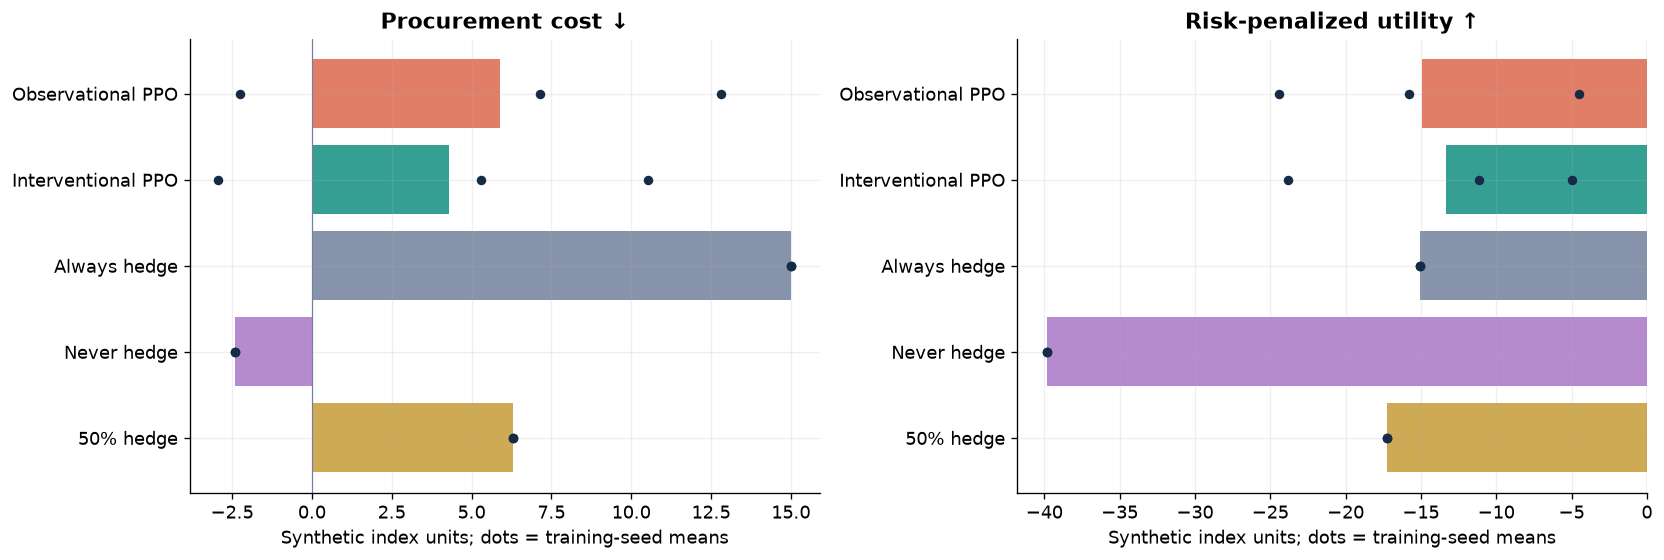

,Observational cost − interventional cost
Training seed,
11,1.838
22,2.281
33,0.685


**Measured paired cost reduction: +1.601 index units.** The mean raw-cost comparison favors **interventional** training in this run. Compare the utility and fixed-hedge baselines before drawing a conclusion.

In [12]:
order = list(COLORS)
display(summary.loc[order].round(3))
seed_means = per_run.groupby(["seed", "policy"])[["total_cost", "total_utility"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, column, title in zip(axes, ["total_cost", "total_utility"],
                           ["Procurement cost ↓", "Risk-penalized utility ↑"]):
    means = [seed_means.xs(label, level="policy")[column].mean() for label in order]
    ax.barh(order, means, color=[COLORS[label] for label in order], alpha=0.85)
    for i, label in enumerate(order):
        values = seed_means.xs(label, level="policy")[column].values
        ax.scatter(values, np.full(len(values), i), color="#162c46", s=22, zorder=3)
    ax.invert_yaxis()
    ax.axvline(0, color="#71809b", linewidth=0.7)
    ax.set(title=title, xlabel="Synthetic index units; dots = training-seed means")
fig.tight_layout()
plt.show()

paired = pd.Series(metrics["paired_cost_reduction_by_seed"], name="Observational cost − interventional cost")
display(paired.rename_axis("Training seed").to_frame().round(3))
delta = metrics["paired_cost_reduction_mean"]
winner = "interventional" if delta > 0 else "observational" if delta < 0 else "neither"
display(Markdown(f"**Measured paired cost reduction: {delta:+.3f} index units.** "
                 f"The mean raw-cost comparison favors **{winner}** training in this run. "
                 "Compare the utility and fixed-hedge baselines before drawing a conclusion."))


## 8 · Inspect behavior, rather than assuming the story

A lower average cost does not establish that the agent discovered a crisp Q4 rule. Plot the deployed mean hedge and inspect the exact week-40 under-hedging probabilities. In the reference run, learned-policy differences are modest. There is **no assumed or targeted 94% result**.

The chart pools weeks across two held-out years and the test paths. The table separates the two calendar years; neither is a pre-entry training statistic.


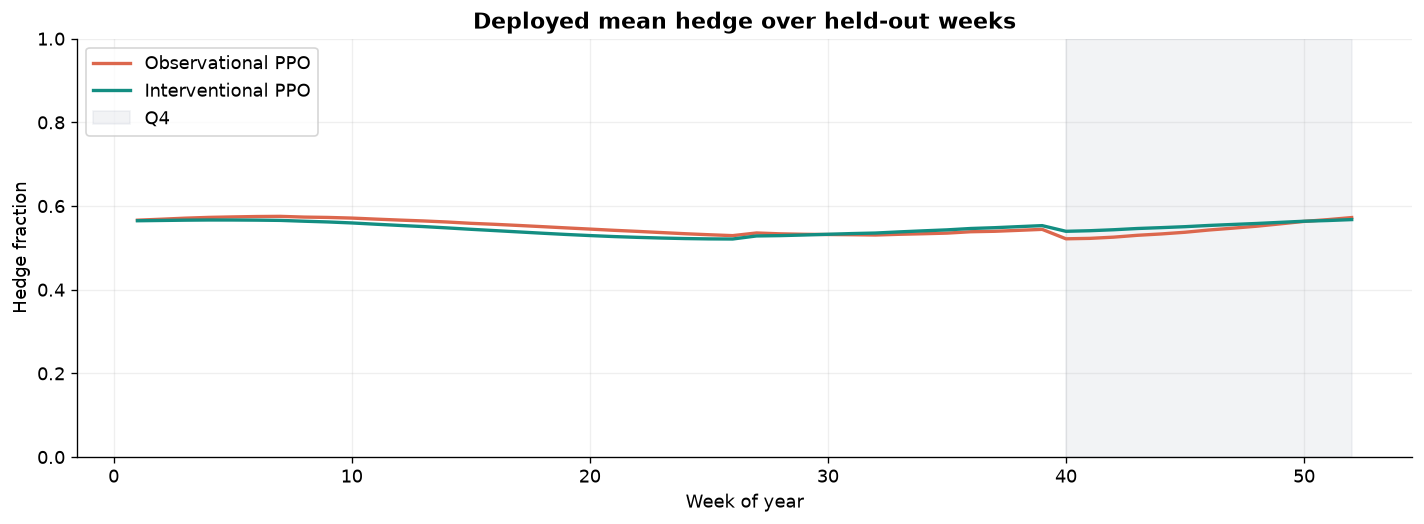

mean_deployed_hedge  probability_below_half
year policy                                                         
9    Interventional PPO                0.539                   0.310
     Observational PPO                 0.521                   0.315
10   Interventional PPO                0.539                   0.311
     Observational PPO                 0.522                   0.315

In [13]:
learned = evaluation[evaluation.policy.isin(["Observational PPO", "Interventional PPO"])]
fig, ax = plt.subplots(figsize=(12, 4.5))
for label in ["Observational PPO", "Interventional PPO"]:
    curve = learned[learned.policy == label].groupby("week").hedge.mean()
    ax.plot(curve.index, curve.values, label=label, color=COLORS[label], linewidth=2)
ax.axvspan(40, 52, color="#71809b", alpha=0.09, label="Q4")
ax.set(title="Deployed mean hedge over held-out weeks", xlabel="Week of year", ylabel="Hedge fraction", ylim=(0, 1))
ax.legend()
fig.tight_layout()
plt.show()
week40 = learned[learned.week == 40].groupby(["year", "policy"]).agg(
    mean_deployed_hedge=("hedge", "mean"),
    probability_below_half=("p_under_half", "mean"),
)
display(week40.round(3))


## 9 · Real market context: WTI
<a id="9-Real-market-context:-WTI"></a>

These daily published spot prices come from **U.S. EIA via FRED**, not from the SCM. The data helps place the discussion in a real market context. It is **not used for model training, causal-effect estimation, or normalization** in the experiment above.

This is not an intraday feed. Recent observations may be delayed or revised. The provenance record includes the retrieval timestamp, date range and SHA-256 of the CSV. The parser retains negative historical prices and drops missing observations.

The complete loading code is below. By default we use the separate repository snapshot; a missing snapshot or `REFRESH_WTI=True` triggers a public download. A failed download raises an error rather than substituting simulated data.


In [14]:
URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"


SOURCE = "https://fred.stlouisfed.org/series/DCOILWTICO"


def parse_csv(raw: bytes) -> pd.DataFrame:
    frame = pd.read_csv(io.BytesIO(raw))
    if len(frame.columns) != 2 or "DCOILWTICO" not in frame:
        raise ValueError("Unexpected FRED CSV schema")
    frame.columns = ["date", "price"]
    frame["date"] = pd.to_datetime(frame["date"], errors="raise")
    frame["price"] = pd.to_numeric(frame["price"], errors="coerce")
    frame = frame.dropna().sort_values("date").drop_duplicates("date")
    if frame.empty:
        raise ValueError("No usable WTI observations returned")
    # Negative WTI prices are valid historical observations, not missing values.
    return frame.reset_index(drop=True)


def fetch(directory: Path) -> dict:
    request = Request(URL, headers={"User-Agent": "Causal-AI-research-demo/0.1"})
    with urlopen(request, timeout=45) as response:
        raw = response.read()
    frame = parse_csv(raw)
    latest = frame.date.max()
    frame = frame[frame.date >= latest - pd.DateOffset(years=10)]
    directory.mkdir(parents=True, exist_ok=True)
    csv = frame.to_csv(index=False).encode()
    (directory / "wti_daily.csv").write_bytes(csv)
    metadata = {
        "series": "DCOILWTICO",
        "source": SOURCE,
        "download_url": URL,
        "provider": "U.S. Energy Information Administration via FRED",
        "units": "USD per barrel",
        "frequency": "daily published observations; not intraday",
        "retrieved_at_utc": datetime.now(UTC).isoformat(),
        "first_observation": frame.date.min().date().isoformat(),
        "last_observation": latest.date().isoformat(),
        "observations": len(frame),
        "sha256": hashlib.sha256(csv).hexdigest(),
        "role": "Market context only; not used to estimate liquidation effects or train PPO",
    }
    (directory / "provenance.json").write_text(json.dumps(metadata, indent=2) + "\n")
    return metadata


,Data provenance
provider,U.S. Energy Information Administration via FRED
first_observation,2016-09-22
last_observation,2026-09-22
retrieved_at_utc,2026-09-24T08:16:18.905819+00:00
observations,2500
role,Market context only; not used to estimate liqu...


,price
date,
2026-09-16,103.62
2026-09-17,103.21
2026-09-18,101.44
2026-09-21,96.97
2026-09-22,96.41


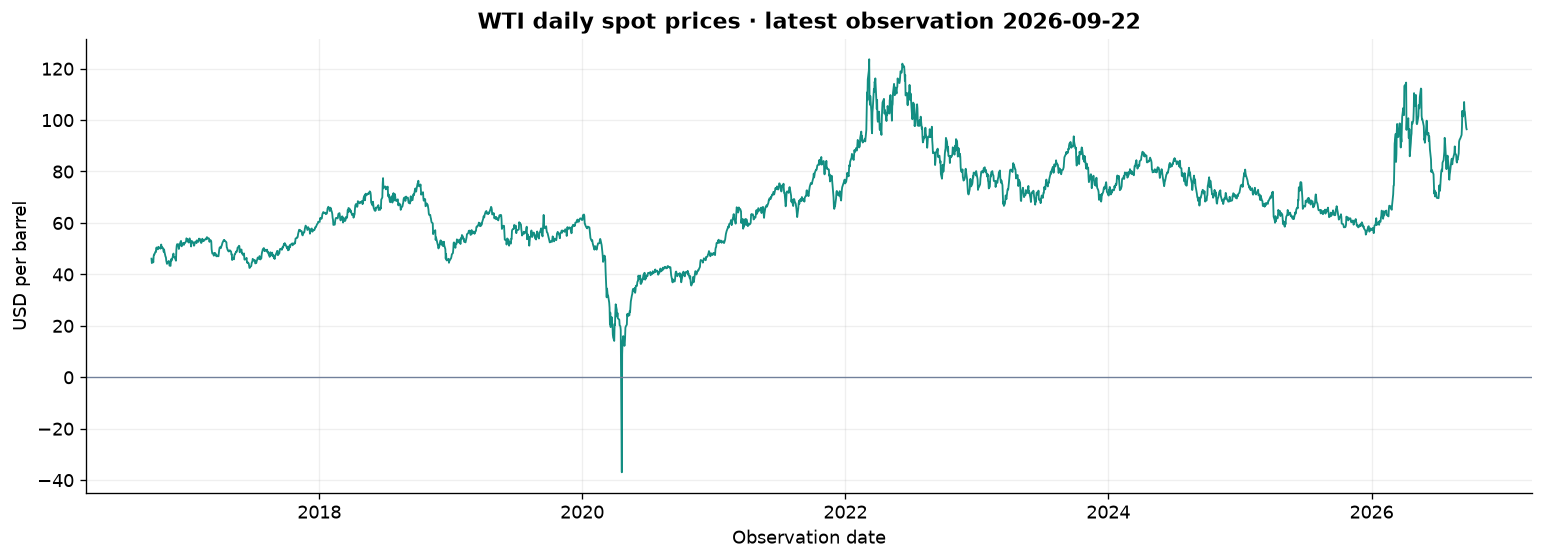

In [15]:
if REFRESH_WTI or not (DATA_DIR / "wti_daily.csv").exists():
    provenance = fetch(DATA_DIR)
else:
    provenance = json.loads((DATA_DIR / "provenance.json").read_text())
raw_csv = (DATA_DIR / "wti_daily.csv").read_bytes()
assert hashlib.sha256(raw_csv).hexdigest() == provenance["sha256"]
wti = pd.read_csv(io.BytesIO(raw_csv), parse_dates=["date"])
display(pd.Series({k: provenance[k] for k in ["provider", "first_observation", "last_observation",
                                             "retrieved_at_utc", "observations", "role"]},
                  name="Data provenance").to_frame())
display(wti.tail().set_index("date"))
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(wti.date, wti.price, color="#138e82", linewidth=1.1)
ax.axhline(0, color="#71809b", linewidth=0.8)
ax.set(title=f"WTI daily spot prices · latest observation {provenance['last_observation']}",
       xlabel="Observation date", ylabel="USD per barrel")
fig.tight_layout()
plt.show()


## 10 · What this experiment establishes—and what remains open

The simulator demonstrates how a company's historical action can contribute to an observed seasonal pattern, and how explicit interventions produce distinct training worlds. The paired evaluation measures the consequences under one specified regime shift.

The reported policy effect is modest, and depends on the objective, optimization budget, seeds and stress assumptions. The never-hedged policy may win on raw cost while losing on downside utility; always hedging limits exposure at a cost. Those tradeoffs are part of the result.

**It does not establish:**

- that real WTI seasonality was caused by this company's liquidation;
- that the Transformer discovered a 94%-probability seasonal strategy;
- that observational data identified the causal coefficients;
- that an SCM universally improves an RL policy or prevents unseen-shock losses.

Liquidation is tied to season before entry. Separating its real-world effect from exogenous seasonality would require additional assumptions, intervention variation, measurements or an identification strategy. Here that separation is supplied by the simulator designer.

### Sensible next experiments

1. Expand the training-seed count and report paired uncertainty at the seed level.
2. Vary liquidation impact, entry timing and shock size across a predeclared stress grid.
3. Add procurement constraints, actual hedge prices and transaction economics.
4. Estimate a causal model only when intervention records and a defensible identification strategy are available.

### Reproducibility and references

All experiment definitions are visible above and tested directly from this notebook. Compact reference metrics are retained in `results/`; detailed evaluation rows are regenerated in `notebook-runs/` when you run all cells. Earlier package and demo versions remain available in Git history. After changing the experiment, restart the kernel and run all cells before publishing updated outputs.

- [PPO objective and implementation guidance](https://spinningup.openai.com/en/latest/algorithms/ppo.html)
- [Pearl: A Causal Calculus for Statistical Research](https://proceedings.mlr.press/r0/pearl95a.html)
- [FRED DCOILWTICO](https://fred.stlouisfed.org/series/DCOILWTICO)
- [Repository and reference results](https://github.com/sandipdikshit/Causal-AI)
